In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from AdaBoostRegressor_cardekho import y_train, y_pred

from decisionTreeClassifier_CarEvaluation import preprocessor

from transformation_bostonHousePrices import y_train_transformed, y_pred_original

In [2]:
data = pd.read_csv("24-medical_cost_personal_datasets.csv")

In [4]:
data

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...,...
1333,1334,50,male,30.970,3,no,northwest,10600.54830
1334,1335,18,female,31.920,0,no,northeast,2205.98080
1335,1336,18,female,36.850,0,no,southeast,1629.83350
1336,1337,21,female,25.800,0,no,southwest,2007.94500


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Id        1338 non-null   int64  
 1   age       1338 non-null   int64  
 2   sex       1338 non-null   object 
 3   bmi       1338 non-null   float64
 4   children  1338 non-null   int64  
 5   smoker    1338 non-null   object 
 6   region    1338 non-null   object 
 7   charges   1338 non-null   float64
dtypes: float64(2), int64(3), object(3)
memory usage: 83.8+ KB


In [6]:
data.isnull().sum()

Id          0
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [7]:
data.describe()

,Id,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000,1338.000000
mean,669.500000,39.207025,30.663397,1.094918,13270.422265
std,386.391641,14.049960,6.098187,1.205493,12110.011237
min,1.000000,18.000000,15.960000,0.000000,1121.873900
25%,335.250000,27.000000,26.296250,0.000000,4740.287150
50%,669.500000,39.000000,30.400000,1.000000,9382.033000
75%,1003.750000,51.000000,34.693750,2.000000,16639.912515
max,1338.000000,64.000000,53.130000,5.000000,63770.428010


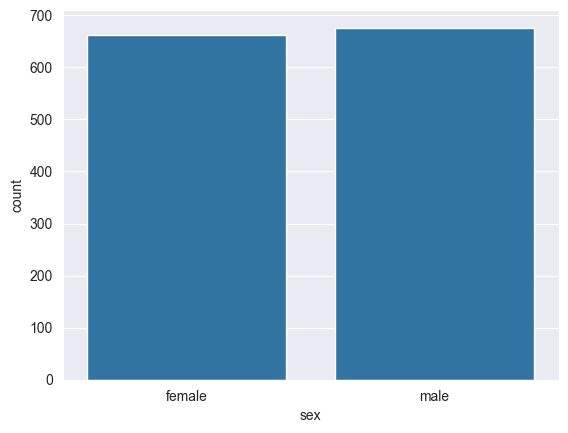

In [8]:
sns.countplot(data=data, x="sex")
plt.show()

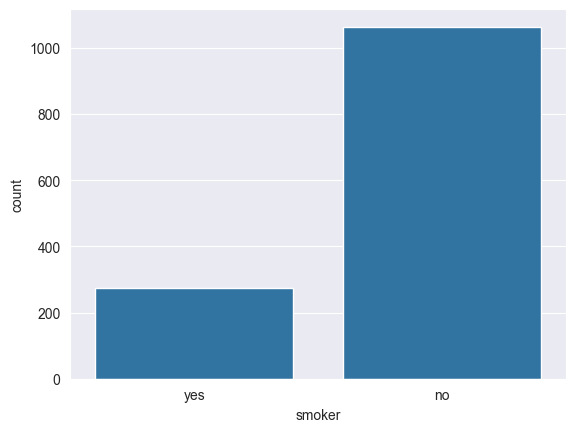

In [9]:
sns.countplot(data=data, x="smoker")
plt.show()

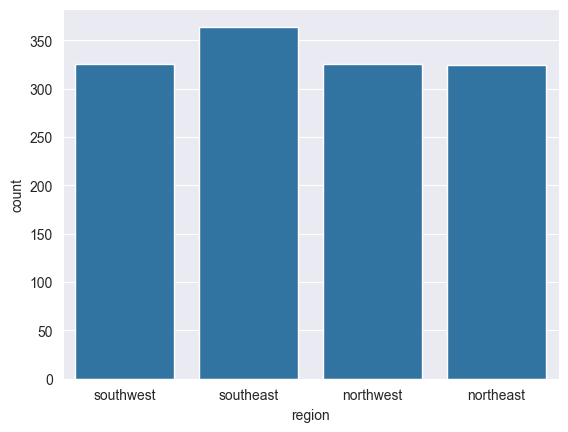

In [10]:
sns.countplot(data=data, x="region")
plt.show()

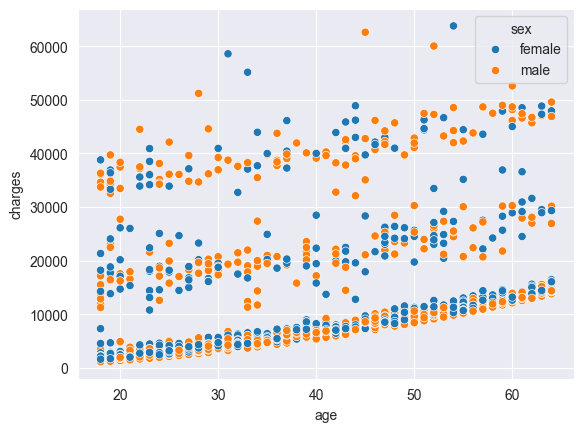

In [12]:
sns.scatterplot(data=data, x="age", y="charges", hue="sex")
plt.show()

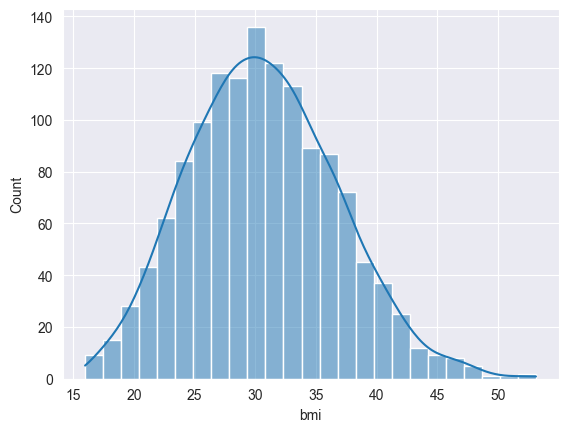

In [14]:
sns.histplot(data=data, x="bmi", kde=True)
plt.show()

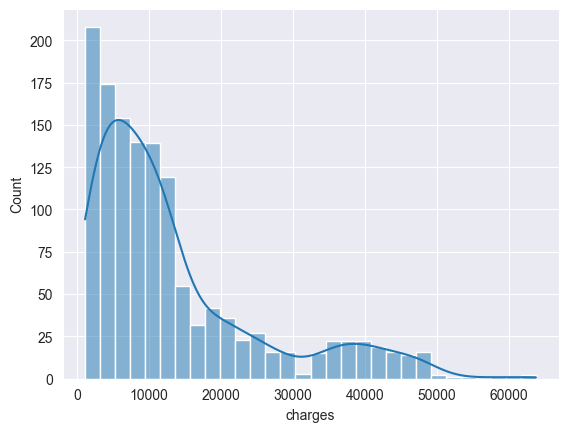

In [15]:
sns.histplot(data=data, x="charges", kde=True)
plt.show()

In [17]:
#feature engineering
data.head()

,Id,age,sex,bmi,children,smoker,region,charges
0,1,19,female,27.900,0,yes,southwest,16884.92400
1,2,18,male,33.770,1,no,southeast,1725.55230
2,3,28,male,33.000,3,no,southeast,4449.46200
3,4,33,male,22.705,0,no,northwest,21984.47061
4,5,32,male,28.880,0,no,northwest,3866.85520


In [18]:
data.drop("Id", inplace=True, axis=1)

In [19]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [20]:
data["sex"] = data["sex"].map({"male": 0, "female": 1})
data["smoker"] = data["smoker"].map({"no": 0, "yes": 1})

In [21]:
data["sex"].value_counts()

sex
0    676
1    662
Name: count, dtype: int64

In [22]:
data["smoker"].value_counts()

smoker
0    1064
1     274
Name: count, dtype: int64

In [23]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(4), object(1)
memory usage: 73.3+ KB


In [24]:
#onehot encoding

X = data.drop("charges", axis=1)
y = data["charges"]

In [25]:
from sklearn.model_selection import train_test_split

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=15)

In [27]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [28]:
categorical_columns = ["region"]

preprocessor = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore", drop="first"), categorical_columns),
    ], remainder="passthrough"
)

X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [30]:
from lightgbm import LGBMRegressor

In [31]:
model = LGBMRegressor()
model.fit(X_train, y_train)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001246 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 319
[LightGBM] [Info] Number of data points in the train set: 1003, number of used features: 8
[LightGBM] [Info] Start training from score 13374.181390


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [32]:
y_pred = model.predict(X_test)

D:\PycharmProjects\MachineLearningNotes\.venv\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [33]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

In [34]:
print("R2 Score: ", r2_score(y_test, y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error: ", mean_squared_error(y_test, y_pred))

R2 Score:  0.871843376594573
Mean Absolute Error:  2770.071293021704
Mean Squared Error:  18458085.613847945


In [37]:
# https://lightgbm.readthedocs.io/en/latest/Parameters-Tuning.html
# https://lightgbm.readthedocs.io/en/latest/Parameters.html
# https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMRegressor.html

# hyperparameter tuning

In [38]:
params = {
    "num_leaves": [31,50,70],
    "max_depth": [-1, 5, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "n_estimators": [100, 200, 500, 1000],
    "min_child_weight": [10, 20, 30],
    "subsample": [0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.7, 0.8, 0.9, 1.0],
    "reg_alpha": [0.5, 0, 1.0],
    "reg_lambda": [0.5, 0, 1.0]
}

In [39]:
from sklearn.model_selection import RandomizedSearchCV

In [40]:
import warnings
warnings.filterwarnings("ignore")

In [41]:
rscv = RandomizedSearchCV(estimator= LGBMRegressor(verbose=-1), param_distributions=params, cv=5, verbose=0, scoring="r2", n_jobs=-1)

In [42]:
rscv.fit(X_train, y_train)

,estimator,LGBMRegressor(verbose=-1)
,param_distributions,"{'colsample_bytree': [0.7, 0.8, ...], 'learning_rate': [0.01, 0.05, ...], 'max_depth': [-1, 5, ...], 'min_child_weight': [10, 20, ...], ...}"
,n_iter,10
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,None
,error_score,nan


In [43]:
rscv.best_params_

{'subsample': 1.0,
 'reg_lambda': 1.0,
 'reg_alpha': 0.5,
 'num_leaves': 31,
 'n_estimators': 100,
 'min_child_weight': 10,
 'max_depth': 10,
 'learning_rate': 0.05,
 'colsample_bytree': 1.0}

In [44]:
y_pred = rscv.predict(X_test)

In [45]:
print("R2 Score: ", r2_score(y_test, y_pred))
print("Mean Absolute Error: ", mean_absolute_error(y_test, y_pred))
print("Mean Squared Error: ", mean_squared_error(y_test, y_pred))

R2 Score:  0.8888890595083799
Mean Absolute Error:  2410.730284659845
Mean Squared Error:  16003037.515598593


In [46]:
#Transformation

In [47]:
from scipy.stats import boxcox

In [48]:
y_train_transformed, lambda_y = boxcox(y_train)

In [50]:
model = LGBMRegressor()
model.fit(X_train, y_train_transformed)

,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [51]:
y_train_transformed = model.predict(X_test)

In [52]:
# (inverse Box-Cox)
def inverse_boxcox(y, lambda_):
    if lambda_ == 0:
        return np.exp(y)
    else:
        return np.power(y * lambda_ + 1, 1 / lambda_)

In [53]:
y_pred_original = inverse_boxcox(y_train_transformed, lambda_y)

In [55]:
print("R2 Score: ", r2_score(y_test, y_pred_original))
print("Mean Absolute Error: ", mean_absolute_error(y_test, y_pred_original))
print("Mean Squared Error: ", mean_squared_error(y_test, y_pred_original))

R2 Score:  0.8925898035961266
Mean Absolute Error:  2129.19354753348
Mean Squared Error:  15470028.378876308
